# Drone Scene Editing Pipeline (ChatSim-Inspired)
### End-to-End Implementation for Controllable Scene Editing




## 1. Environment Setup
Install all required packages. Takes ~1-2 minutes on Colab.

In [ ]:
# Install dependencies
#!pip install -q ultralytics opencv-python-headless numpy Pillow matplotlib gradio

import os, sys, json, time, random, logging
from pathlib import Path
from datetime import datetime
from IPython.display import display, Image as IPImage, HTML, clear_output

import numpy as np
import cv2
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("./output")
OUTPUT_DIR.mkdir(exist_ok=True)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
log = logging.getLogger("DroneSceneEdit")

print("All packages installed and imported!")
print(f"   OpenCV: {cv2.__version__}")
print(f"   NumPy:  {np.__version__}")
try:
    import ultralytics
    print(f"   YOLO:   {ultralytics.__version__}")
except:
    pass


All packages installed and imported!
   OpenCV: 4.13.0
   NumPy:  2.4.6
   YOLO:   8.4.58


## 2. Dataset Preparation

> **Challenge Task**: *"Identify and prepare a drone video dataset such as MAVREC"*

**Option A** (default): Synthetic drone-view frames - runs instantly, no download needed.
**Option B**: Download real VisDrone sample (uncomment in next cell).

### Datasets you can explore:
- **VisDrone** — 288 video clips, 261K frames, 10 object classes, 14 Chinese cities
- **MAVREC** — 2.5 hours of 2.7K drone+ground video, 0.5M frames, 1.1M bounding boxes
- **UAVDT** — 80K frames with weather/lighting variations


In [ ]:
import logging as _logging
log = _logging.getLogger("DroneSceneEdit")
if not log.handlers:
    _logging.basicConfig(level=_logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

# VisDrone class names (10 categories)
VISDRONE_CLASSES = {
    0: "pedestrian", 1: "people", 2: "bicycle", 3: "car",
    4: "van", 5: "truck", 6: "tricycle", 7: "awning-tricycle",
    8: "bus", 9: "motor",
}

# Colors (BGR for OpenCV)
CLASS_COLORS = {
    "pedestrian": (0, 255, 0),   "people": (0, 200, 0),
    "bicycle": (255, 255, 0),    "car": (255, 0, 0),
    "van": (200, 100, 0),        "truck": (0, 100, 255),
    "tricycle": (255, 0, 255),   "awning-tricycle": (200, 0, 200),
    "bus": (0, 200, 255),        "motor": (100, 255, 100),
}


def generate_synthetic_drone_frames(num_frames=60, width=640, height=480, num_objects=12):
    """
    Generate synthetic top-down drone view frames with moving objects.
    Each frame has roads, moving vehicles/pedestrians, and camera shake.
    """
    log.info(f"Generating {num_frames} synthetic drone frames ({width}x{height})")

    objects = []
    for i in range(num_objects):
        obj_type = random.choice(["car","car","car","truck","van","pedestrian","bus"])
        if obj_type in ("car","van"):       w, h = random.randint(30,45), random.randint(18,25)
        elif obj_type in ("truck","bus"):   w, h = random.randint(45,65), random.randint(20,28)
        else:                               w, h = random.randint(8,14), random.randint(8,14)

        x, y = random.randint(50, width-50), random.randint(50, height-50)
        if random.random() > 0.3:
            if random.random() > 0.5:
                vx, vy = random.choice([-1,1])*random.uniform(2,5), random.uniform(-0.3,0.3)
            else:
                vx, vy = random.uniform(-0.3,0.3), random.choice([-1,1])*random.uniform(2,5)
        else:
            vx, vy = random.uniform(-3,3), random.uniform(-3,3)

        objects.append({"id":i, "type":obj_type, "x":float(x), "y":float(y),
                        "w":w, "h":h, "vx":vx, "vy":vy,
                        "color":CLASS_COLORS.get(obj_type,(200,200,200))})

    frames, ground_truth = [], []
    for fi in range(num_frames):
        img = np.full((height,width,3), (40,50,35), dtype=np.uint8)

        # Roads
        cv2.rectangle(img, (0,height//2-30),(width,height//2+30),(80,80,80),-1)
        cv2.rectangle(img, (width//2-30,0),(width//2+30,height),(80,80,80),-1)
        cv2.rectangle(img, (0,height//4-20),(width,height//4+20),(70,70,70),-1)
        cv2.rectangle(img, (width//4-20,0),(width//4+20,height),(70,70,70),-1)

        for ry in [height//4, height//2]:
            for xs in range(0, width, 30):
                cv2.line(img, (xs,ry), (xs+15,ry), (120,120,120), 1)
        for rx in [width//4, width//2]:
            for ys in range(0, height, 30):
                cv2.line(img, (rx,ys), (rx,ys+15), (120,120,120), 1)

        for bx,by,bw,bh in [(50,50,60,40),(400,300,80,60),(500,50,70,50)]:
            cv2.rectangle(img, (bx,by),(bx+bw,by+bh),(50,60,50),-1)

        dx, dy = int(np.sin(fi*0.1)*2), int(np.cos(fi*0.15)*2)
        frame_gt = []
        for obj in objects:
            obj["x"] += obj["vx"]; obj["y"] += obj["vy"]
            if obj["x"] < -20: obj["x"] = width+10
            if obj["x"] > width+20: obj["x"] = -10
            if obj["y"] < -20: obj["y"] = height+10
            if obj["y"] > height+20: obj["y"] = -10

            x1,y1 = int(obj["x"]-obj["w"]/2)+dx, int(obj["y"]-obj["h"]/2)+dy
            x2,y2 = x1+obj["w"], y1+obj["h"]
            x1c,y1c,x2c,y2c = max(0,x1),max(0,y1),min(width,x2),min(height,y2)

            if x2c>x1c and y2c>y1c:
                cv2.rectangle(img,(x1c,y1c),(x2c,y2c),obj["color"],-1)
                cv2.rectangle(img,(x1c,y1c),(x2c,y2c),tuple(c//2 for c in obj["color"]),1)
                frame_gt.append({"id":obj["id"],"type":obj["type"],"bbox":[x1c,y1c,x2c-x1c,y2c-y1c]})

        frames.append(img); ground_truth.append(frame_gt)
    log.info(f"Generated {len(frames)} frames with {num_objects} objects")
    return frames, ground_truth, objects


def load_real_drone_video(video_path, max_frames=60):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened(): return [], []
    frames = []
    while len(frames) < max_frames:
        ret, frame = cap.read()
        if not ret: break
        frames.append(cv2.resize(frame, (640, 480)))
    cap.release()
    return frames, []


def show_frame(frame, title="", figsize=(10,7)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=14, fontweight="bold"); plt.axis("off"); plt.tight_layout(); plt.show()

def show_frames_grid(frames_list, titles=None, cols=3, figsize=(16,5)):
    rows = (len(frames_list)+cols-1)//cols
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows==1 and cols>1: axes = [axes]
    elif rows==1 and cols==1: axes = [[axes]]
    elif cols==1: axes = [[ax] for ax in axes]
    for idx, frame in enumerate(frames_list):
        r, c = idx//cols, idx%cols
        axes[r][c].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if titles and idx < len(titles): axes[r][c].set_title(titles[idx], fontsize=10)
        axes[r][c].axis("off")
    for idx in range(len(frames_list), rows*cols):
        r, c = idx//cols, idx%cols
        axes[r][c].axis("off")
    plt.tight_layout(); plt.show()

print("Dataset utilities ready!")

Dataset utilities ready!


## 3. Import Data

In [ ]:
# # OPTION A: Synthetic (default — no download needed)
# frames, ground_truth, scene_objects = generate_synthetic_drone_frames(
#     num_frames=60, width=640, height=480, num_objects=12
# )

# show_frames_grid(
#     [frames[0], frames[20], frames[40]],
#     titles=["Frame 0", "Frame 20", "Frame 40"], figsize=(16,5),
# )
# print(f"Dataset: {len(frames)} frames, {len(scene_objects)} objects")


Available VisDrone sequences (7):
  [0] uav0000086_00000_v  (464 frames, ann=✓)
  [1] uav0000117_02622_v  (349 frames, ann=✓)
  [2] uav0000137_00458_v  (233 frames, ann=✓)
  [3] uav0000182_00000_v  (363 frames, ann=✓)
  [4] uav0000268_05773_v  (978 frames, ann=✓)
  [5] uav0000305_00000_v  (184 frames, ann=✓)
  [6] uav0000339_00001_v  (275 frames, ann=✓)

Loading sequence [0]: uav0000086_00000_v


2026-06-09 16:13:10,639 [INFO] Loaded 60 frames, 37 unique tracks from 'uav0000086_00000_v'


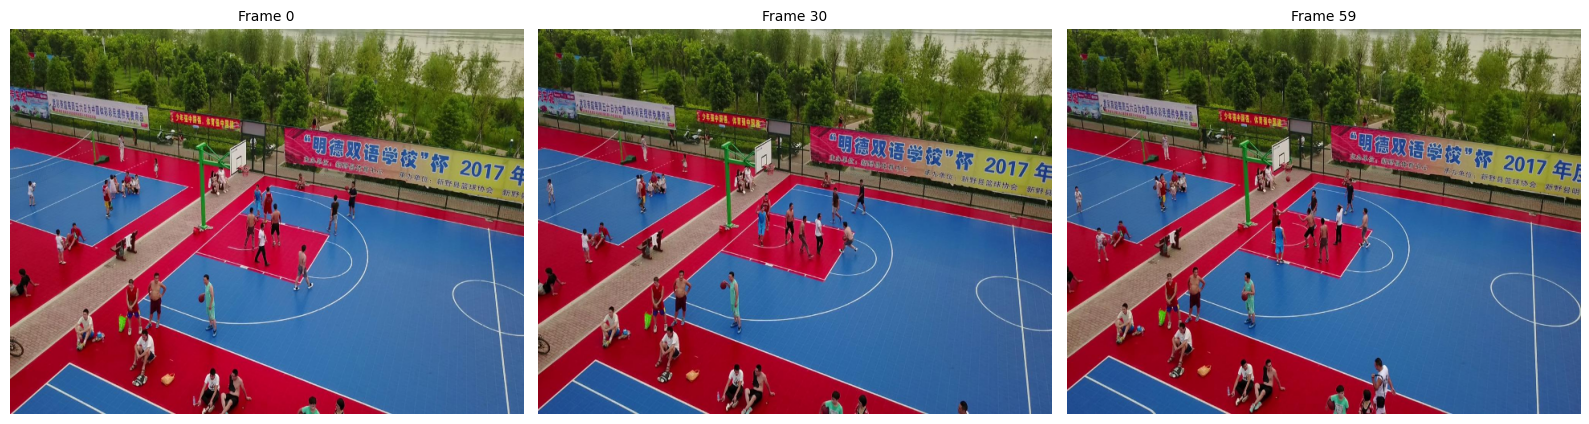

Dataset: 60 frames, 37 unique tracked objects


In [ ]:
# OPTION B: Local VisDrone data (VisDrone2019-MOT-val image sequences)
import logging as _logging
log = _logging.getLogger("DroneSceneEdit")
if not log.handlers:
    _logging.basicConfig(level=_logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")

VISDRONE_DATA_DIR = Path("./VisDrone-data/VisDrone2019-MOT-val")
_SEQ_DIR  = VISDRONE_DATA_DIR / "sequences"
_ANN_DIR  = VISDRONE_DATA_DIR / "annotations"

# VisDrone annotation category index (1-based as stored in .txt files)
_VD_CAT = {
    1: "pedestrian", 2: "people",  3: "bicycle", 4: "car",
    5: "van",        6: "truck",   7: "tricycle", 8: "awning-tricycle",
    9: "bus",       10: "motor",
}

def load_visdrone_sequence(seq_name, max_frames=60, target_size=(640, 480)):
    """Load a VisDrone MOT image sequence with its ground-truth annotations.

    Returns (frames, ground_truth, scene_objects) in the same format as
    generate_synthetic_drone_frames so the rest of the notebook works unchanged.
    """
    seq_path = _SEQ_DIR / seq_name
    ann_path = _ANN_DIR / f"{seq_name}.txt"

    frame_files = sorted(seq_path.glob("*.jpg"))[:max_frames]
    if not frame_files:
        raise FileNotFoundError(f"No .jpg images found in {seq_path}")

    # Read first image to get original resolution for bbox scaling
    first = cv2.imread(str(frame_files[0]))
    orig_h, orig_w = first.shape[:2]
    sx = target_size[0] / orig_w
    sy = target_size[1] / orig_h

    # Load and resize frames
    frames = []
    for fp in frame_files:
        img = cv2.imread(str(fp))
        frames.append(cv2.resize(img, target_size))

    # Parse annotations into per-frame ground-truth
    # Format: frame_idx, track_id, x, y, w, h, score, category, truncation, occlusion
    frame_gt_map = {}
    if ann_path.exists():
        with open(ann_path) as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) < 8:
                    continue
                fi, tid = int(parts[0]), int(parts[1])
                x, y, w, h = int(parts[2]), int(parts[3]), int(parts[4]), int(parts[5])
                score, cat  = int(parts[6]), int(parts[7])
                if score == 0 or cat not in _VD_CAT:    # skip ignored / "others"
                    continue
                frame_gt_map.setdefault(fi, []).append({
                    "id":   tid,
                    "type": _VD_CAT[cat],
                    "bbox": [int(x*sx), int(y*sy), int(w*sx), int(h*sy)],  # [x,y,w,h]
                })

    # Align ground_truth list with loaded frame files (filenames are 1-based)
    ground_truth = [frame_gt_map.get(int(fp.stem), []) for fp in frame_files]

    # Build scene_objects: one entry per unique tracked object
    seen = {}
    for gt in ground_truth:
        for obj in gt:
            seen.setdefault(obj["id"], obj["type"])
    scene_objects = [{"id": tid, "type": t} for tid, t in seen.items()]

    log.info(f"Loaded {len(frames)} frames, {len(scene_objects)} unique tracks from '{seq_name}'")
    return frames, ground_truth, scene_objects


# ── List available sequences ──────────────────────────────────────────────────
sequences = sorted(d.name for d in _SEQ_DIR.iterdir() if d.is_dir())
print(f"Available VisDrone sequences ({len(sequences)}):")
for i, s in enumerate(sequences):
    n = len(list((_SEQ_DIR / s).glob("*.jpg")))
    ann_ok = "✓" if (_ANN_DIR / f"{s}.txt").exists() else "✗"
    print(f"  [{i}] {s}  ({n} frames, ann={ann_ok})")

# ── Choose sequence (change SEQ_IDX to pick a different one) ─────────────────
SEQ_IDX = 0
chosen_seq = sequences[SEQ_IDX]
print(f"\nLoading sequence [{SEQ_IDX}]: {chosen_seq}")
frames, ground_truth, scene_objects = load_visdrone_sequence(chosen_seq, max_frames=60)

mid = len(frames) // 2
show_frames_grid(
    [frames[0], frames[mid], frames[-1]],
    titles=["Frame 0", f"Frame {mid}", f"Frame {len(frames)-1}"],
    figsize=(16, 5),
)
print(f"Dataset: {len(frames)} frames, {len(scene_objects)} unique tracked objects")


## 4. Object Detection (YOLOv8)

> **Challenge Task**: *"Run one segmentation or tracking model on a short drone clip"*

YOLOv8 auto-downloads (~6MB). In ChatSim, `Agent_Detection` does exactly this.


In [ ]:
class DetectionAgent:
    """
    AGENT 1: Object Detection
    Runs YOLOv8 on each frame. Equivalent to ChatSim's detection component.
    """
    def __init__(self, model_name="yolov8n.pt"):
        try:
            from ultralytics import YOLO
            self.model = YOLO(model_name)
            self.has_yolo = True
            log.info(f"Loaded YOLO model: {model_name}")
        except Exception as e:
            log.warning(f"YOLO not available ({e}). Using fallback.")
            self.has_yolo = False; self.model = None

    def detect(self, frame, conf_threshold=0.25):
        if self.has_yolo:
            results = self.model(frame, conf=conf_threshold, verbose=False)
            detections = []
            for r in results:
                for box in r.boxes:
                    x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
                    detections.append({
                        "bbox": [int(x1),int(y1),int(x2),int(y2)],
                        "class": self.model.names[int(box.cls[0])],
                        "confidence": round(float(box.conf[0]), 3),
                    })
            return detections
        return self._fallback_detect(frame)

    def _fallback_detect(self, frame):
        detections = []
        for color_name, (b,g,r) in CLASS_COLORS.items():
            lower = np.array([max(0,b-40),max(0,g-40),max(0,r-40)])
            upper = np.array([min(255,b+40),min(255,g+40),min(255,r+40)])
            mask = cv2.inRange(frame, lower, upper)
            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for cnt in contours:
                if cv2.contourArea(cnt) > 80:
                    x,y,w,h = cv2.boundingRect(cnt)
                    detections.append({"bbox":[x,y,x+w,y+h], "class":color_name,
                                       "confidence": round(0.7+random.random()*0.25, 3)})
        return detections

    def detect_video(self, frames_list):
        all_dets = []
        for i, f in enumerate(frames_list):
            dets = self.detect(f)
            all_dets.append(dets)
            if i % 20 == 0: log.info(f"  Frame {i}/{len(frames_list)}: {len(dets)} detections")
        return all_dets


detector = DetectionAgent()
print("\nRunning detection on all frames...")
all_detections = detector.detect_video(frames)

total = sum(len(d) for d in all_detections)
print(f"\nDetection Results:")
print(f"   Total detections: {total}")
print(f"   Average per frame: {total/len(all_detections):.1f}")
class_counts = {}
for dets in all_detections:
    for d in dets: class_counts[d["class"]] = class_counts.get(d["class"],0)+1
print(f"   Classes: {dict(sorted(class_counts.items(), key=lambda x:-x[1]))}")


2026-06-09 16:13:23,035 [INFO] Loaded YOLO model: yolov8n.pt
2026-06-09 16:13:23,116 [INFO]   Frame 0/60: 23 detections



Running detection on all frames...


2026-06-09 16:13:24,120 [INFO]   Frame 20/60: 20 detections
2026-06-09 16:13:25,083 [INFO]   Frame 40/60: 23 detections



Detection Results:
   Total detections: 1399
   Average per frame: 23.3
   Classes: {'person': 1319, 'sports ball': 44, 'bus': 27, 'tennis racket': 9}


## 5. Visualization + Tracking

Tracking complete: 57 unique tracks


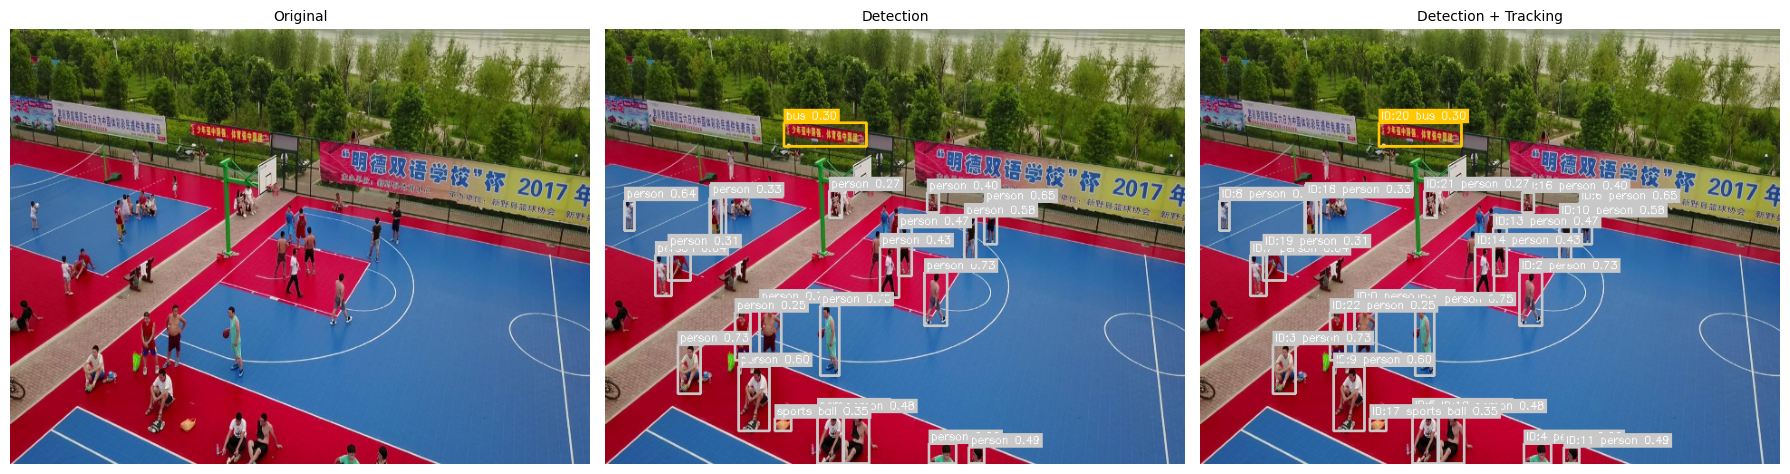

True

In [ ]:
def draw_detections(frame, detections, show_tracks=False):
    result = frame.copy()
    for det in detections:
        x1,y1,x2,y2 = det["bbox"]
        cls = det["class"]; conf = det.get("confidence",0)
        color = CLASS_COLORS.get(cls, (200,200,200))
        cv2.rectangle(result, (x1,y1),(x2,y2), color, 2)
        label = f"{cls} {conf:.2f}"
        if show_tracks and "track_id" in det: label = f"ID:{det['track_id']} {label}"
        (tw,th),_ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
        cv2.rectangle(result, (x1,y1-th-6),(x1+tw+4,y1), color, -1)
        cv2.putText(result, label, (x1+2,y1-4), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
    return result


class TrackingAgent:
    """Simplified IoU-based tracker (like DeepSORT without deep features)."""
    def __init__(self):
        self.tracks = {}; self.next_id = 0

    def update(self, detections):
        if not self.tracks:
            for det in detections:
                det["track_id"] = self.next_id
                self.tracks[self.next_id] = det["bbox"]; self.next_id += 1
            return detections

        unmatched = list(range(len(detections))); matched = {}
        for tid, tbox in list(self.tracks.items()):
            best_iou, best_idx = 0, -1
            for idx in unmatched:
                iou = self._iou(tbox, detections[idx]["bbox"])
                if iou > best_iou: best_iou, best_idx = iou, idx
            if best_iou > 0.2 and best_idx >= 0:
                matched[best_idx] = tid; unmatched.remove(best_idx)

        for idx, det in enumerate(detections):
            if idx in matched:
                det["track_id"] = matched[idx]; self.tracks[matched[idx]] = det["bbox"]
            else:
                det["track_id"] = self.next_id
                self.tracks[self.next_id] = det["bbox"]; self.next_id += 1
        return detections

    @staticmethod
    def _iou(b1, b2):
        x1,y1 = max(b1[0],b2[0]), max(b1[1],b2[1])
        x2,y2 = min(b1[2],b2[2]), min(b1[3],b2[3])
        inter = max(0,x2-x1)*max(0,y2-y1)
        union = (b1[2]-b1[0])*(b1[3]-b1[1]) + (b2[2]-b2[0])*(b2[3]-b2[1]) - inter
        return inter/union if union > 0 else 0


tracker = TrackingAgent()
tracked_detections = []
for dets in all_detections:
    tracked_detections.append(tracker.update(dets))
print(f"Tracking complete: {tracker.next_id} unique tracks")

vis_det = draw_detections(frames[0], all_detections[0])
vis_trk = draw_detections(frames[0], tracked_detections[0], show_tracks=True)
show_frames_grid([frames[0], vis_det, vis_trk],
                 titles=["Original", "Detection", "Detection + Tracking"],
                 figsize=(18,6))
cv2.imwrite(str(OUTPUT_DIR/"detection_result.png"), vis_det)
cv2.imwrite(str(OUTPUT_DIR/"tracking_result.png"), vis_trk)


## 6. ChatSim Core: NLP Parser + Agent Routing

> **Challenge Task**: *"Study key components of ChatSim"*

```
User Command ──► NLP Parser ──► Route to Agent(s) ──► Execute ──► Re-render
```
In real ChatSim, GPT-4 does the parsing. Here we use rule-based parsing (same structure).


In [ ]:
class NLPCommandParser:
    """
    Parses natural language into structured instructions.
    Real ChatSim uses GPT-4; this is rule-based but same structure.
    """
    ACTION_KW = {
        "add":["add","place","put","insert","create"],
        "remove":["remove","delete","erase","clear"],
        "move":["move","shift","relocate","drag"],
        "recolor":["recolor","paint","change color"],
        "count":["count","how many","number of"],
        "detect":["detect","find","identify","segment"],
        "replace":["replace","swap","substitute"],
    }
    OBJECTS = ["car","truck","bus","van","pedestrian","person","bicycle","motorcycle"]
    COLORS = {"red":(0,0,255),"blue":(255,0,0),"green":(0,255,0),"yellow":(0,255,255),
              "white":(255,255,255),"black":(30,30,30),"orange":(0,165,255),"purple":(128,0,128)}

    def parse(self, command):
        lower = command.lower().strip()
        r = {"raw":command, "action":None, "object_type":None,
             "position":None, "color":None, "color_name":None, "agents_needed":[]}

        for act, kws in self.ACTION_KW.items():
            if any(kw in lower for kw in kws): r["action"] = act; break
        for obj in self.OBJECTS:
            if obj in lower: r["object_type"] = obj; break
        for pos in ["left","right","top","bottom","center"]:
            if pos in lower: r["position"] = pos; break
        for cn, bgr in self.COLORS.items():
            if cn in lower: r["color"] = bgr; r["color_name"] = cn; break

        a = r["action"]
        if a == "add":
            r["agents_needed"] = ["Agent_Placement"]
            if r["color"]: r["agents_needed"].append("Agent_Appearance")
        elif a == "remove":  r["agents_needed"] = ["Agent_Removal"]
        elif a == "move":    r["agents_needed"] = ["Agent_Motion"]
        elif a == "recolor": r["agents_needed"] = ["Agent_Appearance"]
        elif a == "detect":  r["agents_needed"] = ["Agent_Detection"]
        elif a == "count":   r["agents_needed"] = ["Agent_Detection"]
        elif a == "replace": r["agents_needed"] = ["Agent_Removal","Agent_Placement"]
        return r

parser = NLPCommandParser()
print("NLP Parser Test:")
print("="*65)
for cmd in ["Add a red truck on the left", "Remove a car",
            "Move truck to the right", "Paint car blue", "Detect objects"]:
    p = parser.parse(cmd)
    print(f'  "{cmd}"')
    print(f'    action={p["action"]}, object={p["object_type"]}, agents={p["agents_needed"]}\n')


NLP Parser Test:
  "Add a red truck on the left"
    action=add, object=truck, agents=['Agent_Placement', 'Agent_Appearance']

  "Remove a car"
    action=remove, object=car, agents=['Agent_Removal']

  "Move truck to the right"
    action=move, object=truck, agents=['Agent_Motion']

  "Paint car blue"
    action=recolor, object=car, agents=['Agent_Appearance']

  "Detect objects"
    action=detect, object=None, agents=['Agent_Detection']



## 7. Scene Editing Agents

| Agent | Function | ChatSim Equivalent |
|---|---|---|
| PlacementAgent | Add objects | 3D asset + NeRF placement |
| RemovalAgent | Remove via inpainting | NeRF re-render without object |
| MotionAgent | Move objects | Trajectory modification |
| AppearanceAgent | Recolor objects | McLight re-estimation |


In [ ]:
class PlacementAgent:
    def execute(self, frame, instr, existing):
        h,w = frame.shape[:2]
        ot = instr.get("object_type","car")
        pos = instr.get("position","center")
        color = instr.get("color") or CLASS_COLORS.get(ot,(200,200,200))
        sizes = {"car":(40,22),"truck":(55,25),"bus":(65,28),"van":(42,24),
                 "pedestrian":(12,12),"person":(12,12),"bicycle":(15,10)}
        ow,oh = sizes.get(ot,(30,20))
        cx,cy = w//2, h//2
        if pos=="left": cx=w//4
        elif pos=="right": cx=3*w//4
        elif pos=="top": cy=h//4
        elif pos=="bottom": cy=3*h//4
        cx += random.randint(-30,30); cy += random.randint(-30,30)
        x1,y1,x2,y2 = cx-ow//2, cy-oh//2, cx+ow//2, cy+oh//2
        result = frame.copy()
        cv2.rectangle(result,(x1,y1),(x2,y2),color,-1)
        cv2.rectangle(result,(x1,y1),(x2,y2),tuple(c//2 for c in color),1)
        log.info(f"  Agent_Placement: Added {ot} at ({cx},{cy})")
        return result, {"type":ot,"bbox":[x1,y1,x2,y2]}


class RemovalAgent:
    def execute(self, frame, instr, detections):
        ot = instr.get("object_type","car"); result = frame.copy()
        target = next((d for d in detections if d["class"]==ot or ot in d["class"]), None)
        if not target:
            log.warning(f"  No {ot} found to remove"); return result, None
        x1,y1,x2,y2 = target["bbox"]; pad=5
        mask = np.zeros(frame.shape[:2], dtype=np.uint8)
        cv2.rectangle(mask,(max(0,x1-pad),max(0,y1-pad)),
                       (min(frame.shape[1],x2+pad),min(frame.shape[0],y2+pad)),255,-1)
        result = cv2.inpaint(result, mask, 7, cv2.INPAINT_TELEA)
        log.info(f"  Agent_Removal: Removed {ot} at ({x1},{y1})-({x2},{y2})")
        return result, target


class MotionAgent:
    def execute(self, frame, instr, detections):
        ot = instr.get("object_type","car"); d = instr.get("position","right")
        target = next((det for det in detections if det["class"]==ot or ot in det["class"]), None)
        if not target:
            log.warning(f"  No {ot} found"); return frame.copy(), None
        x1,y1,x2,y2 = target["bbox"]; ow,oh = x2-x1, y2-y1
        shift = {"left":(-80,0),"right":(80,0),"top":(0,-80),"bottom":(0,80)}
        dx,dy = shift.get(d,(60,0))
        result = frame.copy()
        mask = np.zeros(frame.shape[:2], dtype=np.uint8)
        cv2.rectangle(mask,(max(0,x1-3),max(0,y1-3)),
                       (min(frame.shape[1],x2+3),min(frame.shape[0],y2+3)),255,-1)
        result = cv2.inpaint(result, mask, 5, cv2.INPAINT_TELEA)
        nx1,ny1 = x1+dx, y1+dy
        color = CLASS_COLORS.get(ot,(200,200,200))
        cv2.rectangle(result,(nx1,ny1),(nx1+ow,ny1+oh),color,-1)
        cv2.rectangle(result,(nx1,ny1),(nx1+ow,ny1+oh),tuple(c//2 for c in color),1)
        log.info(f"  Agent_Motion: Moved {ot} {d} by ({dx},{dy})")
        return result, {"old":target["bbox"],"new":[nx1,ny1,nx1+ow,ny1+oh]}


class AppearanceAgent:
    def execute(self, frame, instr, detections):
        ot = instr.get("object_type","car")
        nc = instr.get("color",(0,0,255))
        target = next((d for d in detections if d["class"]==ot or ot in d["class"]), None)
        if not target:
            log.warning(f"  No {ot} found"); return frame.copy()
        x1,y1,x2,y2 = target["bbox"]; result = frame.copy()
        cv2.rectangle(result,(x1,y1),(x2,y2),nc,-1)
        cv2.rectangle(result,(x1,y1),(x2,y2),tuple(c//2 for c in nc),1)
        log.info(f"  Agent_Appearance: Recolored {ot} to {instr.get('color_name','?')}")
        return result

placer = PlacementAgent()
remover = RemovalAgent()
mover = MotionAgent()
appearance_agent = AppearanceAgent()
print("All editing agents initialized!")


All editing agents initialized!


## 8. Execute Edit Scenarios

> **Challenge Task**: *"Prepare 2-3 example drone edit scenarios to test"*

Three scenarios tuned for VisDrone footage (YOLO detects **`person`**, **`bus`** in this sequence):

1. **Add Vehicles** — place cars into a pedestrian-only scene
2. **Remove People** — inpaint over detected persons to clear the court
3. **Move Person + Add Bus** — relocate a player, then insert a bus

2026-06-09 16:13:56,349 [INFO]   Agent_Placement: Added car at (139,268)
2026-06-09 16:13:56,351 [WARNING]   No car found
2026-06-09 16:13:56,353 [INFO]   Agent_Placement: Added truck at (495,270)
2026-06-09 16:13:56,355 [INFO]   Agent_Placement: Added van at (349,345)


SCENARIO 1: Add Vehicles
  > "Add a red car on the left"
  > "Add a truck on the right"
  > "Add a van on the bottom"


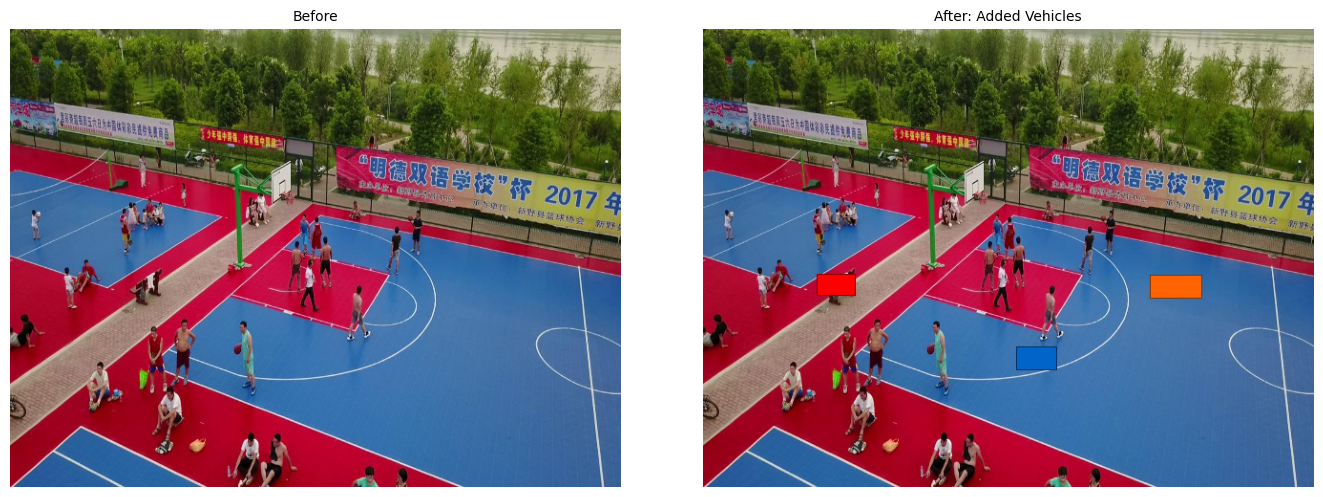


SCENARIO 2: Remove People
  > "Remove a person"


2026-06-09 16:13:56,554 [INFO]   Agent_Removal: Removed person at (236,304)-(255,380)
2026-06-09 16:13:56,563 [INFO]   Agent_Removal: Removed person at (236,304)-(255,380)
2026-06-09 16:13:56,570 [INFO]   Agent_Removal: Removed person at (236,304)-(255,380)


  > "Remove a person"
  > "Remove a person"


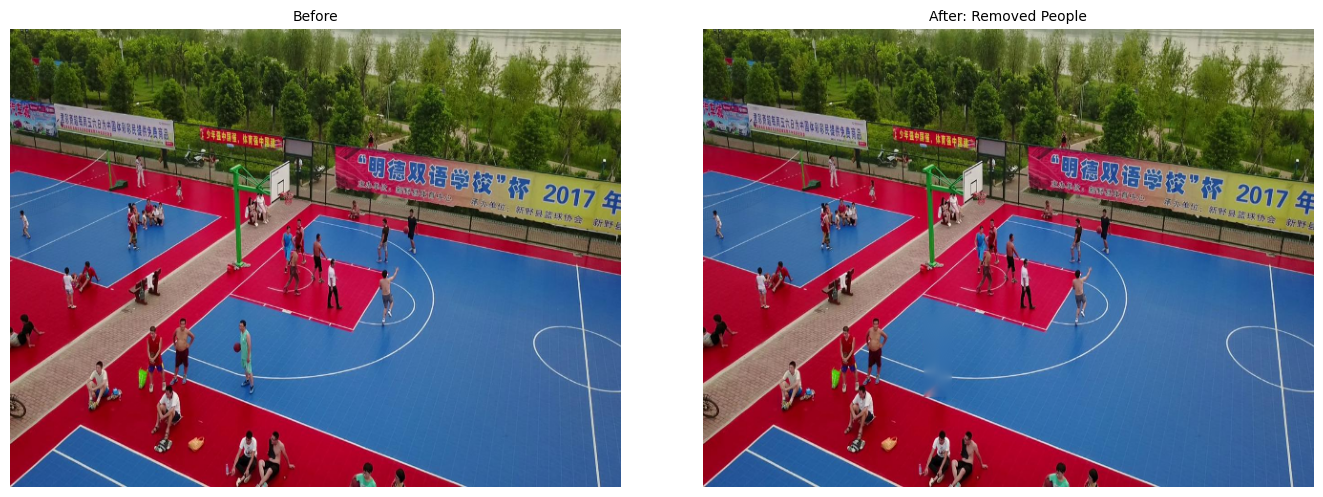

2026-06-09 16:13:56,724 [INFO]   Agent_Motion: Moved person right by (80,0)
2026-06-09 16:13:56,725 [INFO]   Agent_Placement: Added bus at (340,150)
2026-06-09 16:13:56,725 [INFO]   Agent_Appearance: Recolored bus to blue



SCENARIO 3: Move Person + Add Bus
  > "Move person to the right"
  > "Add a blue bus on the top"


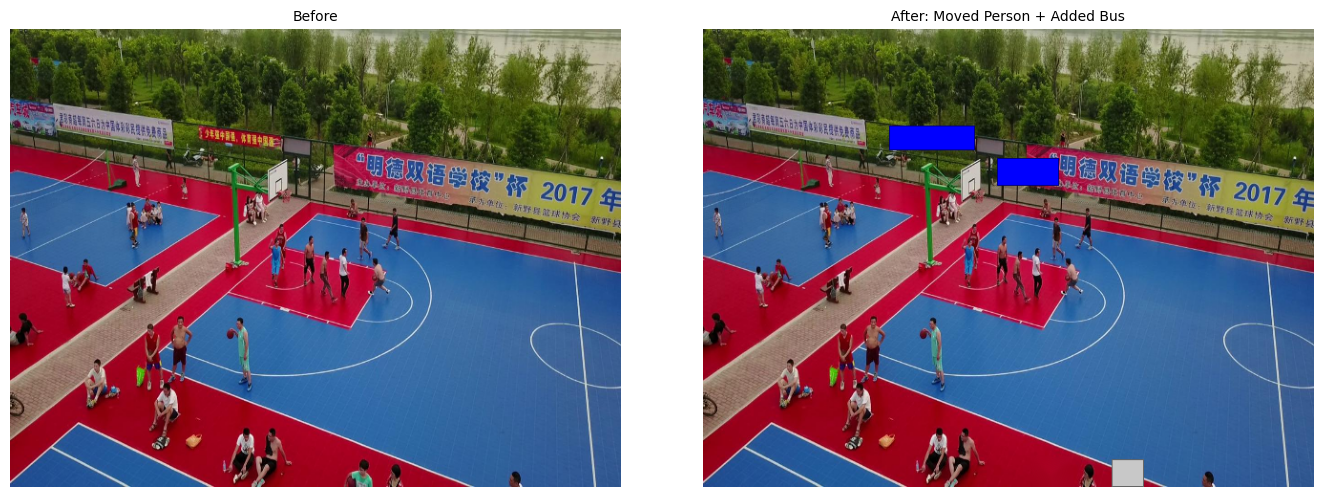


All 3 scenarios complete!


In [ ]:
def execute_command(command, frame, detections):
    instr = parser.parse(command)
    edited = frame.copy()
    for agent in instr["agents_needed"]:
        if agent == "Agent_Placement":    edited, _ = placer.execute(edited, instr, detections)
        elif agent == "Agent_Removal":    edited, _ = remover.execute(edited, instr, detections)
        elif agent == "Agent_Motion":     edited, _ = mover.execute(edited, instr, detections)
        elif agent == "Agent_Appearance": edited = appearance_agent.execute(edited, instr, detections)
        elif agent == "Agent_Detection":
            new_dets = detector.detect(edited)
            edited = draw_detections(edited, new_dets, show_tracks=True)
    return edited, instr


# ── SCENARIO 1: Add Vehicles to a pedestrian scene ──────────────────────────
# YOLO sees only persons here; we add cars/truck that don't exist naturally
print("SCENARIO 1: Add Vehicles")
print("="*50)
f1 = frames[0].copy(); d1 = tracked_detections[0]; orig1 = f1.copy()
for cmd in ["Add a red car on the left", "Add a truck on the right", "Add a van on the bottom"]:
    print(f'  > "{cmd}"'); f1, _ = execute_command(cmd, f1, d1)
show_frames_grid([orig1, f1], titles=["Before", "After: Added Vehicles"], cols=2, figsize=(14,5))
cv2.imwrite(str(OUTPUT_DIR/"scenario1.png"), f1)

# ── SCENARIO 2: Remove People from the scene ────────────────────────────────
# ~23 persons detected per frame — remove several via inpainting
print("\nSCENARIO 2: Remove People")
print("="*50)
f2 = frames[15].copy(); d2 = tracked_detections[15]; orig2 = f2.copy()
for cmd in ["Remove a person", "Remove a person", "Remove a person"]:
    print(f'  > "{cmd}"'); f2, _ = execute_command(cmd, f2, d2)
show_frames_grid([orig2, f2], titles=["Before", "After: Removed People"], cols=2, figsize=(14,5))
cv2.imwrite(str(OUTPUT_DIR/"scenario2.png"), f2)

# ── SCENARIO 3: Move Person + Add a Bus ─────────────────────────────────────
# Move a detected person, then insert a new bus into the scene
print("\nSCENARIO 3: Move Person + Add Bus")
print("="*50)
f3 = frames[30].copy(); d3 = tracked_detections[30]; orig3 = f3.copy()
for cmd in ["Move person to the right", "Add a blue bus on the top"]:
    print(f'  > "{cmd}"'); f3, _ = execute_command(cmd, f3, d3)
show_frames_grid([orig3, f3], titles=["Before", "After: Moved Person + Added Bus"], cols=2, figsize=(14,5))
cv2.imwrite(str(OUTPUT_DIR/"scenario3.png"), f3)
print("\nAll 3 scenarios complete!")

## 9. Interactive Pipeline — Try Your Own Commands!

> **Challenge Task**: *"Implement an initial drone-scene editing pipeline"*


2026-06-09 16:15:14,772 [INFO]   Agent_Removal: Removed person at (236,304)-(255,379)


Command: "Remove a person"
Parsed:  action=remove, object=person, agents=['Agent_Removal']


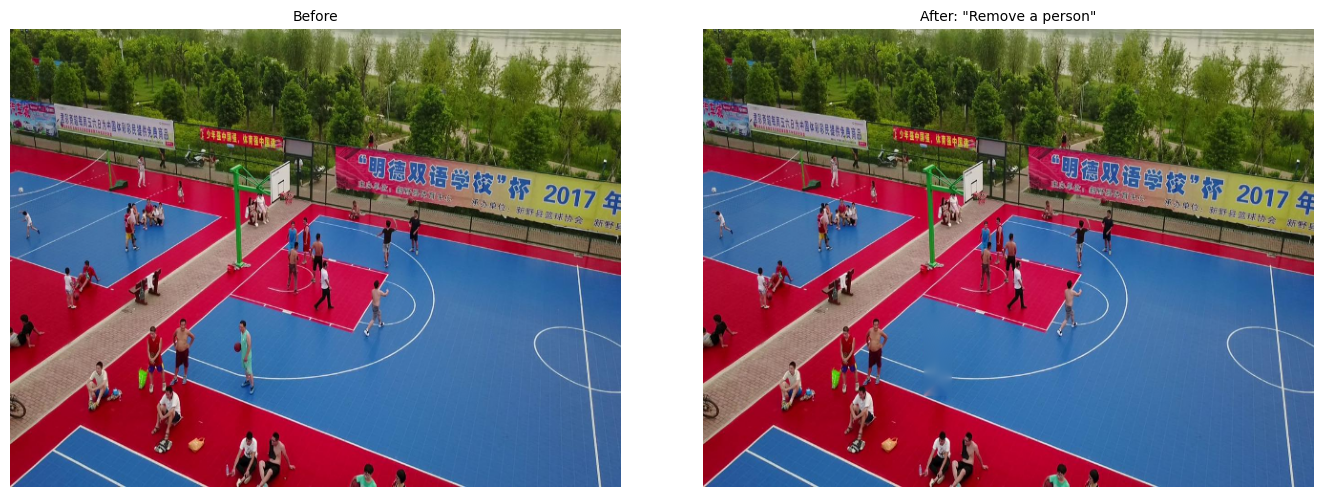

In [ ]:
def run_pipeline(command, frame_idx=0):
    """One-line pipeline: command + frame index → before/after."""
    frame = frames[frame_idx].copy()
    dets = tracked_detections[frame_idx] if frame_idx < len(tracked_detections) else []
    original = frame.copy()
    edited, instr = execute_command(command, frame, dets)

    print(f'Command: "{command}"')
    print(f'Parsed:  action={instr["action"]}, object={instr["object_type"]}, agents={instr["agents_needed"]}')
    show_frames_grid([original, edited], titles=["Before", f'After: "{command}"'], cols=2, figsize=(14,5))
    return original, edited

# ── Try it! Change the command to suit the scene: ──
# Detected in this VisDrone sequence: person, bus
original, edited = run_pipeline("Remove a person", frame_idx=10)

In [ ]:
# More examples — uncomment any line:
# Removal (targets detected objects):
# run_pipeline("Remove a person", frame_idx=5)
# run_pipeline("Remove a bus", frame_idx=20)

# Addition (inserts objects not in the scene):
# run_pipeline("Add a red car on the left", frame_idx=0)
# run_pipeline("Add a truck on the bottom", frame_idx=15)
# run_pipeline("Add a blue van on the right", frame_idx=30)

# Motion (moves a detected object):
# run_pipeline("Move person to the left", frame_idx=10)
# run_pipeline("Move bus to the bottom", frame_idx=25)

# Detection overlay:
# run_pipeline("Detect all objects", frame_idx=0)

print("Detected in this VisDrone sequence: person (~23/frame), bus, sports ball")
print("Supported actions: add / remove / move / paint")
print("Positions: left / right / top / bottom / center")
print("Colors: red / blue / green / yellow / white / orange / purple")

## 10. Interactive Demo (Gradio)

> **Challenge Task**: *"Build a small demo deployment"*

Launches a local web UI. Use `share=True` for a public URL.

In [ ]:
import gradio as gr

def demo_fn(command, frame_idx):
    frame_idx = int(frame_idx)
    if frame_idx >= len(frames): frame_idx = 0
    frame = frames[frame_idx].copy()
    dets = tracked_detections[frame_idx] if frame_idx < len(tracked_detections) else []
    edited, instr = execute_command(command, frame, dets)

    orig_rgb = cv2.cvtColor(frames[frame_idx], cv2.COLOR_BGR2RGB)
    edit_rgb = cv2.cvtColor(edited, cv2.COLOR_BGR2RGB)
    info = f"Action: {instr['action']}\nObject: {instr['object_type']}\nAgents: {', '.join(instr['agents_needed'])}\nDetections: {len(dets)}"
    return orig_rgb, edit_rgb, info

demo = gr.Interface(
    fn=demo_fn,
    inputs=[
        gr.Textbox(label="Command", placeholder="Remove a person"),
        gr.Slider(0, len(frames)-1, value=0, step=1, label="Frame"),
    ],
    outputs=[gr.Image(label="Original"), gr.Image(label="Edited"), gr.Textbox(label="Info")],
    title="Drone Scene Editing Pipeline (VisDrone)",
    description="Detected classes in this sequence: person, bus. Add vehicles, remove/move people.",
    examples=[
        ["Remove a person",           0],
        ["Remove a person",          15],
        ["Add a red car on the left", 10],
        ["Move person to the right",  20],
        ["Add a blue bus on the top", 30],
        ["Move bus to the bottom",    25],
    ],
)
demo.launch(share=True)